In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
file = 'ecommerce.csv'
df = pd.read_csv(file, encoding='latin1')

# Data Understanding

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4870 entries, 0 to 4869
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    4870 non-null   int64  
 1   StockCode    4870 non-null   object 
 2   Description  4870 non-null   object 
 3   Quantity     4870 non-null   int64  
 4   InvoiceDate  4870 non-null   object 
 5   UnitPrice    4870 non-null   float64
 6   CustomerID   4870 non-null   int64  
 7   Country      4870 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 304.5+ KB


In [34]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Analisa Info

- Tidak ada missing value
- Tipe data terdapat 1 kolom yaitu Invoice Date yang seharusnya bertipe data date

In [35]:
df.describe().round(2)

,InvoiceNo,Quantity,UnitPrice,CustomerID
count,4870.00,4870.00,4870.00,4870.00
mean,560586.58,12.95,2.94,15291.00
std,13211.35,38.15,4.74,1709.04
min,536365.00,1.00,0.04,12347.00
25%,548861.00,2.00,1.25,13975.00
50%,561895.00,5.00,1.95,15144.00
75%,572126.00,12.00,3.75,16793.25
max,581585.00,992.00,145.00,18283.00


## Analisa Describe Kolom Numerik

- Kolom Quantity
  - Tidak ada quantity yang negatif
  - Tidak ada quantity yang bernilai 0
  - Mayoritas membeli item sekitar 2 sampai 12 item.
  - Ada transaksi item yang sangat banyak 992 item
  - Pertanyaan: apakah transaksi yang banyak itu merupakan hal wajar atau outlier?
- Kolom UnitPrice
  - Harga barang termurah adalah 0.04
  - harga barang termahal 145
  - Mean lebih besar daripada median -> mengindikasikan distribusi data right skewed
  - terdepat beberapa data yang besar yang menarik data rata rata ke atas

### Check outlier

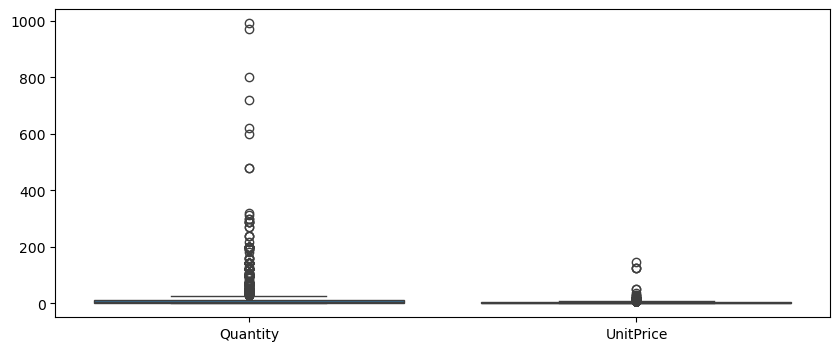

In [36]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df[['Quantity','UnitPrice']])
plt.show()

- Analisa Quantity
  - Sangat banyak data yang berada diatas whisker
  - Distirbusi data sangat memungkinkan right skewed
  - Ada banyak transaksi pembelian dalam jumlah yang besar
 data belum tentu salah, karena bisa saja memang teradapat customer yang membeli dengan jumlah yang besar

- Analisa Unit Price
  - terdapat beberapa data yang melebih outlier namun tidak banyak
  - ini termasuk normal pada sebaran datanya jadi tidak bisa sembarang untuk dihapus

**Insight Sementara** :
Variabel Quantity dan Unit Price memiliki distribusi data yang tidak simetris dan mengandung jumlah outlier. Outlier tersebut tidak bisa langsung dianggap kesalahan karena pada transaksi e-commerce dapat merepresentasikan pembelian dalam jumlah besar atau produk premium

## Analisa Kolom Kategorikal

### Analisa Kolom Country

In [37]:
df['Country'].value_counts()

Country
United Kingdom          4346
Germany                  121
EIRE                      90
France                    89
Switzerland               28
Netherlands               26
Spain                     25
Belgium                   21
Portugal                  16
Norway                    14
Australia                 13
Sweden                    12
Channel Islands            8
Finland                    7
Greece                     7
Austria                    7
Cyprus                     6
Japan                      5
Italy                      5
Unspecified                4
Denmark                    4
Singapore                  3
United Arab Emirates       2
Poland                     2
Canada                     2
Israel                     2
RSA                        1
Lebanon                    1
Iceland                    1
Brazil                     1
Malta                      1
Name: count, dtype: int64

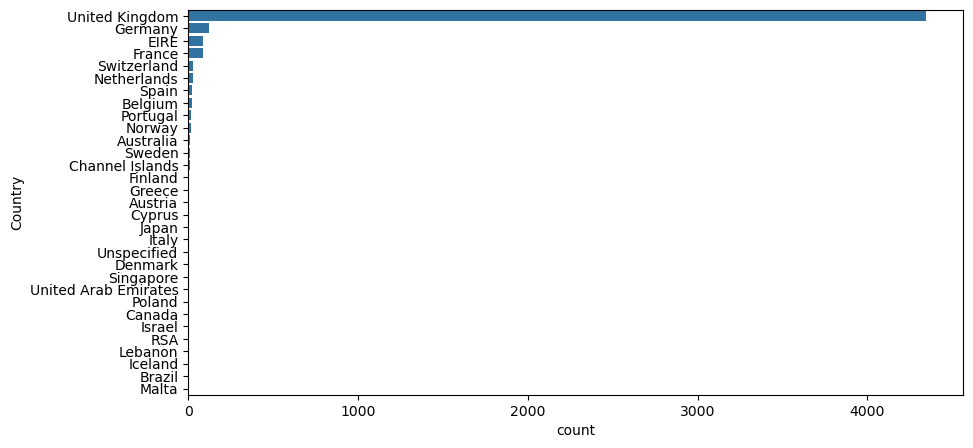

In [38]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='Country',
    data=df,
    order=df['Country'].value_counts().index
)
plt.show()

- Negara yang memiliki transaksi paling banyak yaitu United Kingdom
- United Kingdom sangat mendominasi jumlah transaksinya

## Feature Engineering

In [39]:
# mengubah tipe data date invoice
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# menambah kolom revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

# Menambah kolom tahun, bulan, dan nama bulan
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['MonthName'] = df['InvoiceDate'].dt.month_name()

# Menambah kolom hari dan jam
df['Day'] = df['InvoiceDate'].dt.day
df['Hour'] = df['InvoiceDate'].dt.hour

In [40]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Day,Hour
0,554697,21166,COOK WITH WINE METAL SIGN,1,2011-05-25 17:31:00,2.08,14584,United Kingdom,2.08,2011,5,May,25,17
1,561038,82482,WOODEN PICTURE FRAME WHITE FINISH,2,2011-07-24 11:58:00,2.55,17114,United Kingdom,5.10,2011,7,July,24,11
2,560552,23192,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,1,2011-07-19 12:54:00,1.65,15311,United Kingdom,1.65,2011,7,July,19,12
3,559884,85183B,CHARLIE & LOLA WASTEPAPER BIN FLORA,12,2011-07-13 11:34:00,1.25,16843,United Kingdom,15.00,2011,7,July,13,11
4,544450,21789,KIDS RAIN MAC PINK,3,2011-02-20 12:23:00,0.85,17811,United Kingdom,2.55,2011,2,February,20,12


## Pertanyaan

### Negara yang memiliki revenue terbesar

In [41]:
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

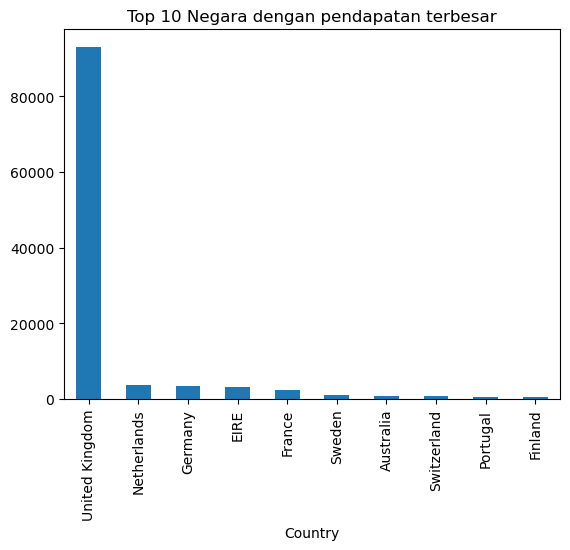

In [42]:
country_revenue.head(10).plot(
    kind='bar'
)
plt.title('Top 10 Negara dengan pendapatan terbesar')
plt.show()

* negara dengan penghasilan tertinggi yaitu United Kingdom

### Produk apa yang paling banyak terjual

In [43]:
top_product = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

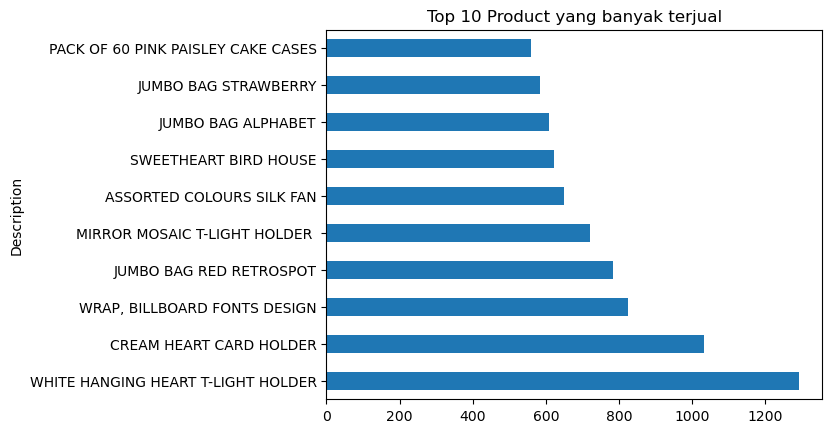

In [44]:
top_product.head(10).plot(
    kind='barh'
)
plt.title('Top 10 Product yang banyak terjual')
plt.show()

Produk dengan penjualan tertinggi yaitu White Hanging Heart T-Light Holder

### Produk yang memiliki revenue terbesar

In [48]:
top_revenue_product = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
)

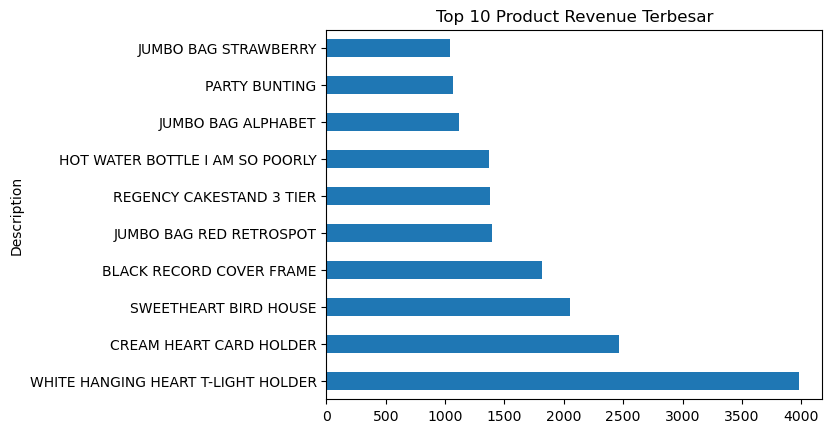

In [50]:
top_revenue_product.head(10).plot(
    kind='barh'
)
plt.title('Top 10 Product Revenue Terbesar')
plt.show()

Product dengan revenue terbesar yaitu White Hanging Heart T-Light Holder

### Bulan yang memiliki penjualan tertinggi

In [53]:
monthly_sales = (
    df.groupby('MonthName')['Revenue']
    .sum()
)
#set pengurutan 
month_order = [
    'January','February','March',
    'April','May','June',
    'July','August','September',
    'October','November','December'
]

monthly_sales = monthly_sales.reindex(month_order)

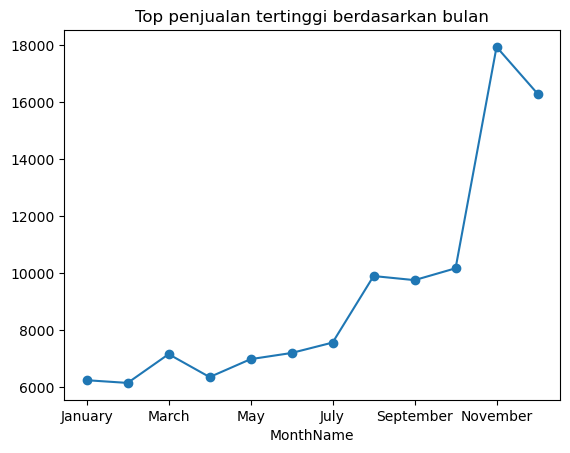

In [54]:
monthly_sales.plot(
    kind='line',
    marker='o'
)
plt.title('Top penjualan tertinggi berdasarkan bulan')
plt.show()

Penjualan tertinggi terjadi pada bulan November

### Pada jam berapa transaksi paling sering terjadi

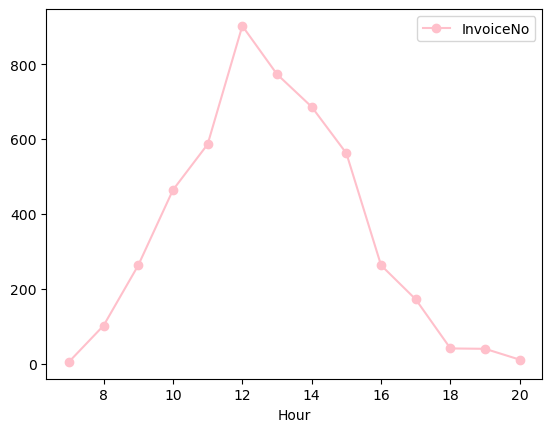

In [58]:
hourly_sales = (
    df.groupby('Hour')
    .agg({
        'InvoiceNo' : 'count'
    })
)
hourly_sales.plot(
    kind='line',
    marker='o',
    color='pink'
)
plt.show()

Berdasarkan grafik diatas, transaksi paling sering terjadi di jam 12

### Faktor mana yang lebih berpengaruh terhadap revenue: Quantity atau UnitPrice ?

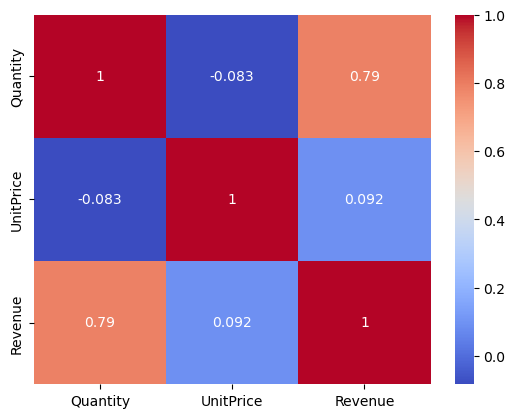

In [59]:
corr = df[['Quantity', 'UnitPrice', 'Revenue']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()

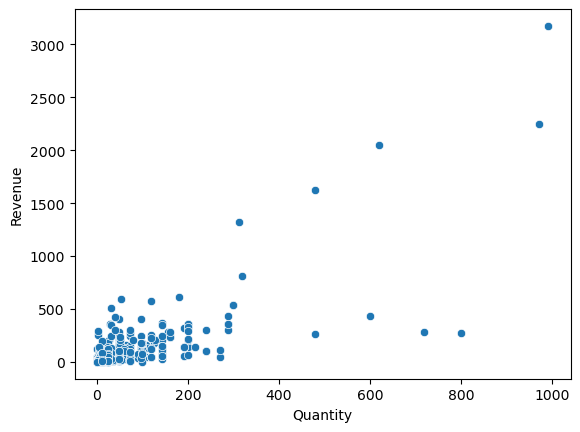

In [60]:
sns.scatterplot(
    data=df,
    x='Quantity',
    y='Revenue',
)
plt.show()

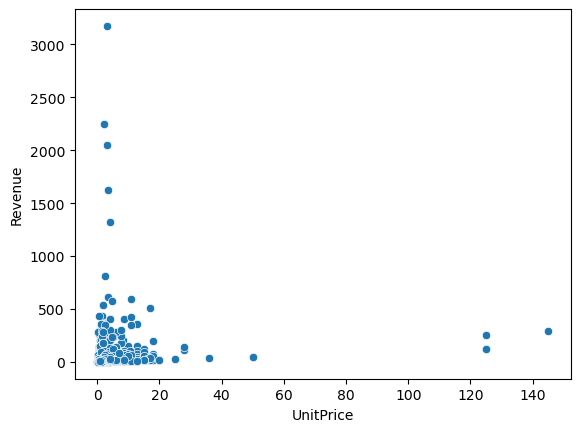

In [61]:
sns.scatterplot(
    data=df,
    x='UnitPrice',
    y='Revenue'
)
plt.show()

Interpretasi
- Quantity memiliki korelasi positif yang kuat sekitar 0.79 terhadap Revenue
- UnitPrice lemah sekitar 0.09
- Quantity dengan dengan UnitPrice hampir tidak memiliki hubungan

Artinya
pendapatan perusahaan lebih banyak dipengaruhi oleh banyak barang yang terjual dibandingkan harga barang